# Day 09. Exercise 03
# Ensembles

## 0. Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, StackingClassifier
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import joblib

## 1. Preprocessing

1. Create the same dataframe as in the previous exercise.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test` and then get `X_train`, `y_train`, `X_valid`, `y_valid` from the previous `X_train`, `y_train`. Use the additional parameter `stratify`.

In [2]:
df = pd.read_csv('../data/day-of-week-not-scaled.csv').reset_index()
df_for_merge = pd.read_csv('../data/dayofweek.csv').reset_index()
df['dayofweek'] = df_for_merge['dayofweek']

df = df.drop(columns='index', axis=1)

X = df.drop('dayofweek', axis=1)
y = df['dayofweek']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

XX = X_train.copy()
yy = y_train.copy()

X_train, X_valid, y_train, y_valid = train_test_split(XX, yy, test_size=0.2, random_state=21, stratify=yy)



X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1078, 43), (338, 43), (1078,), (338,))

## 2. Individual classifiers

1. Train SVM, decision tree and random forest again with the best parameters that you got from the 01 exercise with `random_state=21` for all of them.
2. Evaluate `accuracy`, `precision`, and `recall` for them on the validation set.
3. The result of each cell of the section should look like this:

```
accuracy is 0.87778
precision is 0.88162
recall is 0.87778
```

In [3]:
svc = SVC(
    C = 10, 
    class_weight = None, 
    gamma = 'auto', 
    kernel = 'rbf', 
    random_state = 21, 
    probability=True)

svc = svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'accuracy = {accuracy}\nprecision = {precision}\nrecall = {recall}')

accuracy = 0.878698224852071
precision = 0.8800117828490814
recall = 0.878698224852071


In [4]:
dtc = DecisionTreeClassifier(
    class_weight = 'balanced',
    criterion = 'gini',
    max_depth = 22,
    random_state = 21)

dtc = dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'accuracy = {accuracy}\nprecision = {precision}\nrecall = {recall}')

accuracy = 0.8757396449704142
precision = 0.8788945482674921
recall = 0.8757396449704142


In [5]:
rfc = RandomForestClassifier(
    class_weight = None,
    criterion = 'gini',
    max_depth = 28,
    n_estimators = 50,
    random_state = 21
    )

rfc = rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'accuracy = {accuracy}\nprecision = {precision}\nrecall = {recall}')

accuracy = 0.908284023668639
precision = 0.9095699942273924
recall = 0.908284023668639


## 3. Voting classifiers

1. Using `VotingClassifier` and the three models that you have just trained, calculate the `accuracy`, `precision`, and `recall` on the validation set.
2. Play with the other parameteres.
3. Calculate the `accuracy`, `precision` and `recall` on the test set for the model with the best weights in terms of accuracy (if there are several of them with equal values, choose the one with the higher precision).

In [6]:
vc = VotingClassifier(estimators = [('svc', svc), ('dtc', dtc), ('rfc', rfc)])

vc.fit(X_train, y_train)

print(f"accuracy = {accuracy_score(y_test, y_pred)}")
print(f"precision = {precision_score(y_test, y_pred, average='weighted')}")
print(f"recall = {recall_score(y_test, y_pred, average='weighted')}")

accuracy = 0.908284023668639
precision = 0.9095699942273924
recall = 0.908284023668639


In [7]:
param_grid = {
    'voting': ['hard', 'soft'],
    'weights': [
        None,
        [1, 1, 1],
        [1, 2, 3], 
        [3, 2, 1],
        [4, 1, 4]
    ]
}

grid_search = GridSearchCV(
    estimator=vc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nЛучшие параметры:")
print(grid_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Лучшие параметры:
{'voting': 'soft', 'weights': [4, 1, 4]}


## 4. Bagging classifiers

1. Using `BaggingClassifier` and `SVM` with the best parameters create an ensemble, try different values of the `n_estimators`, use `random_state=21`.
2. Play with the other parameters.
3. Calculate the `accuracy`, `precision`, and `recall` for the model with the best parameters (in terms of accuracy) on the test set (if there are several of them with equal values, choose the one with the higher precision)

In [8]:
bc = BaggingClassifier(
    estimator=svc, 
    n_estimators=100, 
    random_state=21
    )

bc.fit(X_train, y_train)

y_pred = bc.predict(X_test)

print(f"accuracy = {accuracy_score(y_test, y_pred)}")
print(f"precision = {precision_score(y_test, y_pred, average='weighted')}")
print(f"recall = {recall_score(y_test, y_pred, average='weighted')}")

accuracy = 0.8846153846153846
precision = 0.8891697906077357
recall = 0.8846153846153846


In [9]:
param_grid = {
    "n_estimators": [10, 30, 50]
}
stratified_cv = StratifiedKFold(n_splits=3, shuffle=True)

grid_search = GridSearchCV(
    estimator=bc,
    param_grid=param_grid,
    cv=stratified_cv,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nЛучшие параметры:")
print(grid_search.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits

Лучшие параметры:
{'n_estimators': 10}


## 5. Stacking classifiers

1. To achieve reproducibility in this case you will have to create an object of cross-validation generator: `StratifiedKFold(n_splits=n, shuffle=True, random_state=21)`, where `n` you will try to optimize (the details are below).
2. Using `StackingClassifier` and the three models that you have recently trained, calculate the `accuracy`, `precision` and `recall` on the validation set, try different values of `n_splits` `[2, 3, 4, 5, 6, 7]` in the cross-validation generator and parameter `passthrough` in the classifier itself,
3. Calculate the `accuracy`, `precision`, and `recall` for the model with the best parameters (in terms of accuracy) on the test set (if there are several of them with equal values, choose the one with the higher precision). Use `final_estimator=LogisticRegression(solver='liblinear')`.

In [10]:
results = []

for n in range(2, 5):
    for passthrough in [True, False]:
        skf = StratifiedKFold(n_splits=n, random_state=21, shuffle=True)
        stack = StackingClassifier(estimators=[('svc', svc), ('dtc', dtc), ('rfc', rfc)], final_estimator=LogisticRegression(solver='liblinear'), cv=skf)
        
        stack.fit(X_train, y_train)
        y_pred = stack.predict(X_valid)
        
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, average='weighted')
        recall = recall_score(y_valid, y_pred, average='weighted')
        
        results.append({
            'n_splits': n,
            'accuracy': accuracy,
            'precision': precision,
            'passthrough': passthrough,
            'recall': recall
        })

/home/apex/Code/DS/DSB11_ML_Advanced.ID_886524-1/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/apex/Code/DS/DSB11_ML_Advanced.ID_886524-1/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/apex/Code/DS/DSB11_ML_Advanced.ID_886524-1/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear'

In [11]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(['accuracy', 'precision'], ascending=[False, False])
best_params = results_df.iloc[0]
best_params

n_splits              4
accuracy       0.907407
precision      0.909423
passthrough        True
recall         0.907407
Name: 4, dtype: object

In [12]:
skf = StratifiedKFold(n_splits=best_params['n_splits'], random_state=21, shuffle=True)
final_model = StackingClassifier(
    estimators=[('svc', svc), ('dtc', dtc), ('rfc', rfc)],
    final_estimator=LogisticRegression(solver='liblinear'),
    cv=skf,
    passthrough=best_params['passthrough']
)

final_model.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]))
y_pred = final_model.predict(X_test)

print(f"accuracy = {accuracy_score(y_test, y_pred)}")
print(f"precision = {precision_score(y_test, y_pred, average='weighted')}")
print(f"recall = {recall_score(y_test, y_pred, average='weighted')}")

accuracy = 0.9171597633136095
precision = 0.9202554871200359
recall = 0.9171597633136095


/home/apex/Code/DS/DSB11_ML_Advanced.ID_886524-1/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


## 6. Predictions

1. Choose the best model in terms of accuracy (if there are several of them with equal values, choose the one with the higher precision).
2. Analyze: for which weekday your model makes the most errors (in % of the total number of samples of that class in your full dataset), for which labname and for which users.
3. Save the model.

In [13]:
df = pd.merge(X_test, y_test, left_index=True, right_index=True)
df['prediction'] = y_pred

def show_most_errors(name):
    columns_to_select = df.columns.str.contains(name)
    selected_columns = df.columns[columns_to_select]
    df['is_correct'] = df['prediction'] == df['dayofweek']
    
    name_df = pd.merge(df[selected_columns], df[['is_correct']], left_index=True, right_index=True)
    
    grouped = name_df.groupby('is_correct').sum()
    
    count = name_df.shape[0]
    
    grouped = grouped.apply(lambda x: x / count * 100).fillna(0)
    grouped = grouped[grouped.index == False]

    
    plt.figure(figsize=(10,8))
    plt.title(f"Процент ошибок по {name}")
    plt.barh(grouped.columns, grouped.values.ravel(), color='blue')
    plt.xlabel('Errors %')
    
    plt.show()

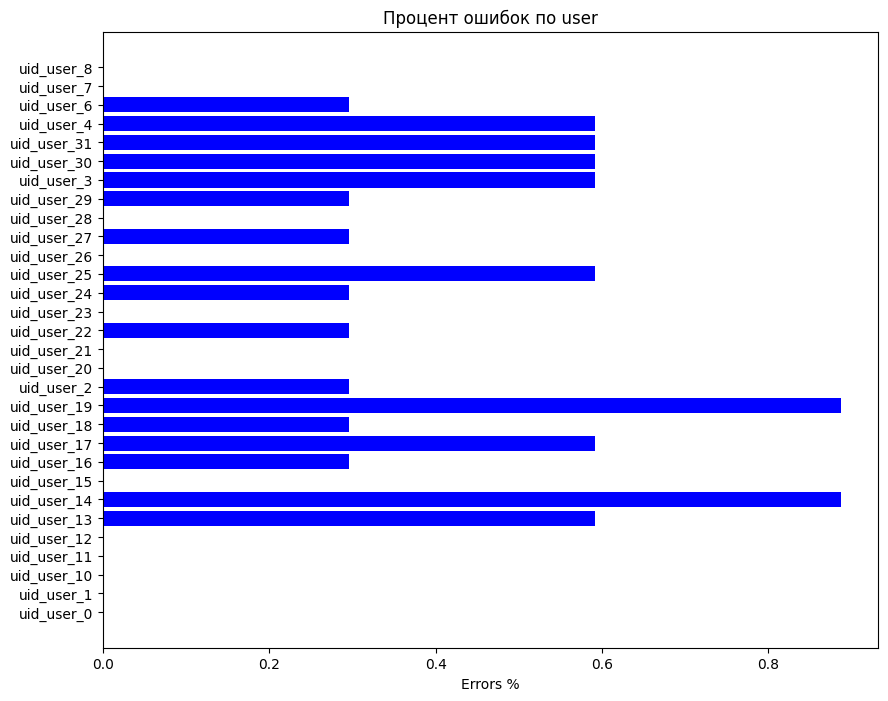

In [14]:
show_most_errors('user')

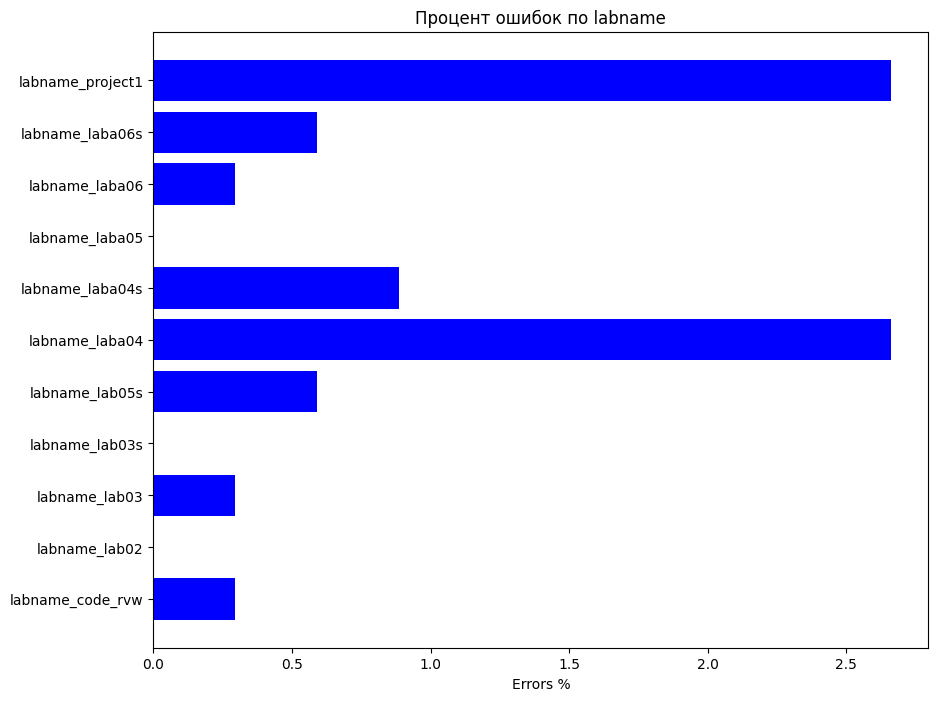

In [15]:
show_most_errors('labname')

In [16]:
joblib.dump(rfc, '../data/model_03.pkl')

['../data/model_03.pkl']